In [ ]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [18]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os

import sys

sys.path.append("../..")

# Modern import pattern - unified simulation method with strategy pattern
from src import Multicolour_Simulation_Functions
from src.Multicolour_Simulation_Functions import FittingStrategy, SimulationConfig

# Additional required components not integrated into main simulation class
from src import PlottingBase
from src import SpectralFunctions
from src import MaskFunctions
from src import HelperFunctions
from src import SpotDetectionFunctions

# Create main simulation instance (contains IO, PSF, sCMOS, ImageAnalysis dependencies)
MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

# Access integrated components through MSF
IO = MSF.io
I_AF = MSF.image_analysis
sCMOS = MSF.scmos
PSF = MSF.psf

# Create instances of non-integrated components
plotter = PlottingBase.PublicationPlotter()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
H_F = HelperFunctions.Helper_Functions()
SD_F = SpotDetectionFunctions.SpotDetection_Functions()

In [2]:
from scipy import ndimage
from typing import Literal, cast
from numpy.typing import NDArray
from numpy import (
    array,
    float32,
    float64,
    ones,
    zeros,
    logical_and,
    logical_or,
    transpose,
    where,
)

# Type aliases
NDArrayFloat = NDArray[np.float64]
ArrayLike = NDArray | list | tuple


def as_float_array(array: ArrayLike) -> NDArrayFloat:
    """Convert input to float64 array."""
    return np.asarray(array, dtype=float64)


def masks_CFA_Bayer(
    shape: tuple[int, int], pattern: str = "RGGB"
) -> tuple[NDArrayFloat, NDArrayFloat, NDArrayFloat]:
    """
    Return the Bayer CFA red, green and blue masks for given pattern.

    Parameters
    ----------
    shape
        Shape of the CFA.
    pattern
        Arrangement of the colour filters on the pixel array.

    Returns
    -------
    tuple
        Red, green and blue masks.
    """
    pattern = pattern.upper()

    r = zeros(shape)
    g = zeros(shape)
    b = zeros(shape)

    # Create masks based on pattern
    if pattern == "RGGB":
        r[0::2, 0::2] = 1
        g[0::2, 1::2] = 1
        g[1::2, 0::2] = 1
        b[1::2, 1::2] = 1
    elif pattern == "BGGR":
        b[0::2, 0::2] = 1
        g[0::2, 1::2] = 1
        g[1::2, 0::2] = 1
        r[1::2, 1::2] = 1
    elif pattern == "GRBG":
        g[0::2, 0::2] = 1
        r[0::2, 1::2] = 1
        b[1::2, 0::2] = 1
        g[1::2, 1::2] = 1
    elif pattern == "GBRG":
        g[0::2, 0::2] = 1
        b[0::2, 1::2] = 1
        r[1::2, 0::2] = 1
        g[1::2, 1::2] = 1
    else:
        raise ValueError("Invalid pattern. Choose from: RGGB, BGGR, GRBG, GBRG")

    return r, g, b


def weighted_convolve(
    image: NDArrayFloat, kernel: NDArrayFloat, weights: NDArrayFloat
) -> NDArrayFloat:
    """
    Perform a weighted convolution where each pixel's contribution is scaled by its weight.
    This version properly handles the case when all weights are 1 (should equal standard convolution).

    Parameters
    ----------
    image
        Input image to convolve.
    kernel
        Convolution kernel.
    weights
        Weight matrix (same shape as image).

    Returns
    -------
    :class:`numpy.ndarray`
        Convolved result.
    """
    kernel_height, kernel_width = kernel.shape
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    # Pad the image and weights
    image_padded = np.pad(
        image, ((pad_height, pad_height), (pad_width, pad_width)), mode="reflect"
    )
    weights_padded = np.pad(
        weights, ((pad_height, pad_height), (pad_width, pad_width)), mode="reflect"
    )

    result = np.zeros_like(image)

    # Precompute the sum of the kernel for normalization
    kernel_sum = np.sum(kernel)

    # Perform weighted convolution
    for i in range(pad_height, image.shape[0] + pad_height):
        for j in range(pad_width, image.shape[1] + pad_width):
            # Extract patches
            image_patch = image_padded[
                i - pad_height : i + pad_height + 1, j - pad_width : j + pad_width + 1
            ]
            weights_patch = weights_padded[
                i - pad_height : i + pad_height + 1, j - pad_width : j + pad_width + 1
            ]

            # Calculate weighted sum
            weighted_kernel = kernel * weights_patch
            weighted_sum = np.sum(image_patch * weighted_kernel)

            # Normalize by the sum of the weighted kernel
            weight_sum = np.sum(weighted_kernel)
            # Avoid division by zero - fall back to standard convolution
            if abs(weight_sum) > 1e-12:
                result[i - pad_height, j - pad_width] = weighted_sum / weight_sum
            else:
                # Fallback: use standard convolution
                result[i - pad_height, j - pad_width] = (
                    np.sum(image_patch * kernel) / kernel_sum
                )

    return result


def tstack(a: ArrayLike) -> NDArrayFloat:
    """
    Stack the given array of images along the last dimension.

    Parameters
    ----------
    a
        Array of images to stack.

    Returns
    -------
    :class:`numpy.ndarray`
        Stacked images.
    """
    a = as_float_array(a)
    return np.concatenate([x[..., None] for x in a], axis=-1)


def demosaicing_CFA_Bayer_Malvar2004_sCMOS(
    CFA: ArrayLike,
    variance_map: ArrayLike,
    pattern: Literal["RGGB", "BGGR", "GRBG", "GBRG"] | str = "RGGB",
    offset_map: ArrayLike | None = None,
    gain: float = 1.0,
) -> NDArrayFloat:
    """
    Return the demosaiced *RGB* colourspace array from given *Bayer* CFA using
    *Malvar (2004)* demosaicing algorithm with sCMOS variance weighting.

    Parameters
    ----------
    CFA
        *Bayer* CFA.
    variance_map
        Variance map for each pixel in the CFA.
    pattern
        Arrangement of the colour filters on the pixel array.
    offset_map
        Offset map for each pixel in the CFA (optional).
    gain
        System gain in electrons per ADU (optional).

    Returns
    -------
    :class:`numpy.ndarray`
        *RGB* colourspace array.

    References
    ----------
    :cite:`Malvar2004a`
    """
    CFA = np.squeeze(as_float_array(CFA))
    variance_map = np.squeeze(as_float_array(variance_map))

    # Apply offset correction if provided
    if offset_map is not None:
        offset_map = np.squeeze(as_float_array(offset_map))
        CFA = CFA - offset_map

    # Convert to electrons if gain is provided
    CFA = CFA / gain
    # variance_map = variance_map / (gain ** 2)  # Variance scales with gain squared

    # Calculate weights from variance (inverse variance weighting)
    weights = 1 / (variance_map)  # Add small value to avoid division by zero

    R_m, G_m, B_m = masks_CFA_Bayer(CFA.shape, pattern)

    # Define Malvar kernels
    GR_GB = (
        as_float_array(
            [
                [0.0, 0.0, -1.0, 0.0, 0.0],
                [0.0, 0.0, 2.0, 0.0, 0.0],
                [-1.0, 2.0, 4.0, 2.0, -1.0],
                [0.0, 0.0, 2.0, 0.0, 0.0],
                [0.0, 0.0, -1.0, 0.0, 0.0],
            ]
        )
        / 8
    )

    Rg_RB_Bg_BR = (
        as_float_array(
            [
                [0.0, 0.0, 0.5, 0.0, 0.0],
                [0.0, -1.0, 0.0, -1.0, 0.0],
                [-1.0, 4.0, 5.0, 4.0, -1.0],
                [0.0, -1.0, 0.0, -1.0, 0.0],
                [0.0, 0.0, 0.5, 0.0, 0.0],
            ]
        )
        / 8
    )

    Rg_BR_Bg_RB = np.transpose(Rg_RB_Bg_BR)

    Rb_BB_Br_RR = (
        as_float_array(
            [
                [0.0, 0.0, -1.5, 0.0, 0.0],
                [0.0, 2.0, 0.0, 2.0, 0.0],
                [-1.5, 0.0, 6.0, 0.0, -1.5],
                [0.0, 2.0, 0.0, 2.0, 0.0],
                [0.0, 0.0, -1.5, 0.0, 0.0],
            ]
        )
        / 8
    )

    R = CFA * R_m
    G = CFA * G_m
    B = CFA * B_m

    del G_m

    # Apply weighted convolution for green channel
    G = np.where(
        np.logical_or(R_m == 1, B_m == 1), weighted_convolve(CFA, GR_GB, weights), G
    )

    # Apply weighted convolution for other channels
    RBg_RBBR = cast(NDArrayFloat, weighted_convolve(CFA, Rg_RB_Bg_BR, weights))
    RBg_BRRB = cast(NDArrayFloat, weighted_convolve(CFA, Rg_BR_Bg_RB, weights))
    RBgr_BBRR = cast(NDArrayFloat, weighted_convolve(CFA, Rb_BB_Br_RR, weights))

    del GR_GB, Rg_RB_Bg_BR, Rg_BR_Bg_RB, Rb_BB_Br_RR

    # Red rows.
    R_r = np.transpose(np.any(R_m == 1, axis=1)[None]) * ones(R.shape)
    # Red columns.
    R_c = np.any(R_m == 1, axis=0)[None] * ones(R.shape)
    # Blue rows.
    B_r = np.transpose(np.any(B_m == 1, axis=1)[None]) * ones(B.shape)
    # Blue columns
    B_c = np.any(B_m == 1, axis=0)[None] * ones(B.shape)

    del R_m, B_m

    # Apply the interpolated values based on pixel position
    R = np.where(np.logical_and(R_r == 1, B_c == 1), RBg_RBBR, R)
    R = np.where(np.logical_and(B_r == 1, R_c == 1), RBg_BRRB, R)

    B = np.where(np.logical_and(B_r == 1, R_c == 1), RBg_RBBR, B)
    B = np.where(np.logical_and(R_r == 1, B_c == 1), RBg_BRRB, B)

    R = np.where(np.logical_and(B_r == 1, B_c == 1), RBgr_BBRR, R)
    B = np.where(np.logical_and(R_r == 1, R_c == 1), RBgr_BBRR, B)

    del RBg_RBBR, RBg_BRRB, RBgr_BBRR, R_r, R_c, B_r, B_c

    return tstack([R, G, B])

In [3]:
def variance_aware_malvar_demosaic(
    CFA: NDArrayFloat,
    variance_map: NDArrayFloat,
    pattern: str = "RGGB",
    offset_map: NDArrayFloat | None = None,
    gain: float = 1.0,
) -> NDArrayFloat:
    """
    Alternative approach to variance-aware Malvar demosaicing.
    Applies variance weighting to the input before standard Malvar demosaicing.
    """
    CFA = np.squeeze(as_float_array(CFA))
    variance_map = np.squeeze(as_float_array(variance_map))

    # Apply offset correction if provided
    if offset_map is not None:
        offset_map = np.squeeze(as_float_array(offset_map))
        CFA = CFA - offset_map

    # Convert from ADU to photoelectrons
    CFA_pe = CFA / gain
    variance_pe = variance_map / (gain**2)

    # Calculate weights from variance (inverse variance weighting)
    weights = 1.0 / (variance_pe + 1e-12)

    # Apply variance weighting to the CFA data
    # This reduces the influence of noisy pixels before demosaicing
    weighted_CFA = CFA_pe * weights

    # Normalize by the average weight to maintain overall intensity
    avg_weight = np.mean(weights)
    weighted_CFA = weighted_CFA / avg_weight

    # Now apply standard Malvar demosaicing to the weighted CFA
    # (Using the original demosaicing_CFA_Bayer_Malvar2004 function without variance weighting)
    result, _ = sCMOS.bayer_demosaic_stack(weighted_CFA)

    return result

In [4]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [5]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
filters = [notch_filter, dichroic_mirror, shortpass_filter]

In [107]:
n_photon = 1000
pixel_size = 69
background_photons = 40

In [108]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [109]:
image_size = 200
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
# camera_parameters = {}
# camera_parameters["gain"] = gain[:image_size, :image_size]
# camera_parameters["variance"] = variance[:image_size, :image_size]
# camera_parameters["readnoise"] = readnoise[:image_size, :image_size]
# camera_parameters["offset"] = offset[:image_size, :image_size]
# camera_parameters["rqe"] = rqe[:image_size, :image_size]

start_point_x = np.random.randint(low=0, high=variance.shape[0] - image_size)
start_point_y = np.random.randint(low=0, high=variance.shape[1] - image_size)

camera_parameters = {}
camera_parameters["gain"] = gain[
    start_point_x : start_point_x + image_size,
    start_point_y : start_point_y + image_size,
]
camera_parameters["variance"] = variance[
    start_point_x : start_point_x + image_size,
    start_point_y : start_point_y + image_size,
]
camera_parameters["readnoise"] = readnoise[
    start_point_x : start_point_x + image_size,
    start_point_y : start_point_y + image_size,
]
camera_parameters["offset"] = offset[
    start_point_x : start_point_x + image_size,
    start_point_y : start_point_y + image_size,
]
camera_parameters["rqe"] = rqe[
    start_point_x : start_point_x + image_size,
    start_point_y : start_point_y + image_size,
]

camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks
dye = "ATTO 565"

x = np.linspace(0.05, 0.95, 19)

X, Y = np.meshgrid(x, x)
X = X.ravel()
Y = Y.ravel()
positions = np.array([X * (image_size * pixel_size), Y * (image_size * pixel_size)])

In [110]:
NA = 1.49
s = 1
n_photons = {}
x0y0 = {}
n_photons[dye] = np.full(s, n_photon)
x0y0[dye] = np.zeros([s, 2, len(positions[0])])
x0y0[dye][:, :, :] = np.array([[positions[0], positions[1]]])

In [111]:
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)


bayer_image_example, smoothed_image, normal_image = MSF.gen_camera_image_stack(
    camera_parameters,
    wavelength,
    average_emission_wavelengths,
    dye_pixel_efficiency,
    n_photons,
    x0y0,
    smoothing_function=smoothing_function,
    background_colour=[1, 0.5, 0.5],
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
    return_normal_image=True,
)

In [112]:
test = variance_aware_malvar_demosaic(
    bayer_image_example,
    variance_map=camera_parameters["variance"],
    gain=camera_parameters["gain"],
    offset_map=camera_parameters["offset"],
)

In [113]:
photoelectrons = IO.convert_to_photoelectrons(
    bayer_image_example,
    gain_map=camera_parameters["gain"],
    offset_map=camera_parameters["offset"],
    rqe=camera_parameters["rqe"],
)

In [114]:
test2, _ = sCMOS.bayer_demosaic_stack(photoelectrons)

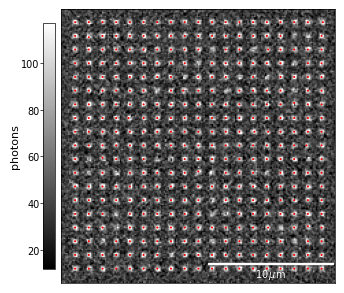

In [115]:
detected_puncta = SD_F.detect_puncta_in_image(
    image=np.sum(test, axis=-1), pfa=1e-3, sigma=0, fraction_true=0
)
fig, axs = plotter.one_column_plot()

axs = plotter.image_scatter_plot(
    axs,
    np.sum(test, axis=-1),
    xdata=detected_puncta[:, 0],
    ydata=detected_puncta[:, 1],
    s=0.5,
)

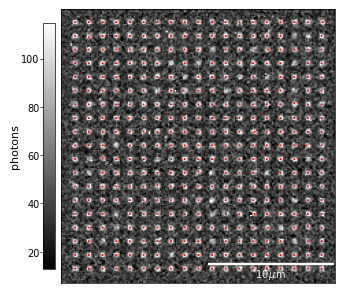

In [121]:
detected_puncta_old = SD_F.detect_puncta_in_image(
    image=np.sum(test2, axis=-1),
    variance=camera_parameters["variance"],
    pfa=1e-3,
    sigma=0,
    fraction_true=0,
)
fig, axs = plotter.one_column_plot()

axs = plotter.image_scatter_plot(
    axs,
    np.sum(test2, axis=-1),
    xdata=detected_puncta_old[:, 0],
    ydata=detected_puncta_old[:, 1],
    s=0.5,
)